In [396]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [397]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [398]:
fdtdApi = lumapi.FDTD(hide=False)

#units

um = 1e-6
nm = 1e-9

## Especificações das simensões do guia e materiais ##

In [399]:
# Dimensions
gap = 200*nm
wvg_width = 0.45*um
wvg_height = 0.22*um
rad = 10*um
Lc = 12.091488*um

# Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

## Criação dos objetos do dispositivo ##

In [400]:
fdtdApi.addrect()
fdtdApi.set('name', 'core_1')
fdtdApi.set('x', 0)
fdtdApi.set('x span', Lc)
fdtdApi.set('y', (gap+wvg_width)/2)
fdtdApi.set('y span', wvg_width)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

fdtdApi.addobject('90_bend_wg')
fdtdApi.set('name', '90_bend_1')
fdtdApi.set('radius', rad)
fdtdApi.set('base height', wvg_height)
fdtdApi.set('base width', wvg_width)
fdtdApi.set('x', Lc/2)
fdtdApi.set('y', rad+(gap+wvg_width)/2)
fdtdApi.set('z', 0)
fdtdApi.set('first axis', 'x')
fdtdApi.set('rotation 1', 180)
fdtdApi.set('material', material)

fdtdApi.addobject('90_bend_wg')
fdtdApi.set('name', '90_bend_2')
fdtdApi.set('radius', rad)
fdtdApi.set('base height', wvg_height)
fdtdApi.set('base width', wvg_width)
fdtdApi.set('x', -Lc/2)
fdtdApi.set('y', rad+(gap+wvg_width)/2)
fdtdApi.set('z', 0)
fdtdApi.set('first axis', 'x')
fdtdApi.set('second axis', 'y')
fdtdApi.set('rotation 1', 180)
fdtdApi.set('rotation 2', 180)
fdtdApi.set('material', material)

fdtdApi.addrect()
fdtdApi.set('name', 'core_2')
fdtdApi.set('x', 0)
fdtdApi.set('x span', Lc + 2*rad)
fdtdApi.set('y', -(gap+wvg_width)/2)
fdtdApi.set('y span', wvg_width)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

In [401]:
# add guias auxiliares
fdtdApi.addrect()
fdtdApi.set('name', 'rect_1')
fdtdApi.set('x', -(rad + Lc/2))
fdtdApi.set('x span', wvg_width)
fdtdApi.set('y', rad + (gap+wvg_width)/2 + 1*um)
fdtdApi.set('y span', 2*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

fdtdApi.addrect()
fdtdApi.set('name', 'rect_2')
fdtdApi.set('x', (rad + Lc/2))
fdtdApi.set('x span', wvg_width)
fdtdApi.set('y', rad + (gap+wvg_width)/2 + 1*um)
fdtdApi.set('y span', 2*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

fdtdApi.addrect()
fdtdApi.set('name', 'rect_3')
fdtdApi.set('x', -(Lc/2 + rad + 1*um))
fdtdApi.set('x span', 2*um)
fdtdApi.set('y', -(gap+wvg_width)/2)
fdtdApi.set('y span', wvg_width)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

fdtdApi.addrect()
fdtdApi.set('name', 'rect_4')
fdtdApi.set('x', Lc/2 + rad + 1*um)
fdtdApi.set('x span', 2*um)
fdtdApi.set('y', -(gap+wvg_width)/2)
fdtdApi.set('y span', wvg_width)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)


## Definindo o solver FDTD ##

In [402]:
x_fdtd = 0
x_span_fdtd = Lc + 2*rad + 2*um
y_fdtd = rad/2
y_span_fdtd = gap + wvg_width + rad + 2*um
z_fdtd = 0
z_span_fdtd = 4*um

wavelength = 1550*nm
start_wavelength = 1500*nm
stop_wavelength = 1600*nm
number_of_frequency_points = 51
mesh_accuracy = 3

z_min_bc = 'Symmetric'

In [403]:
# add solver
fdtdApi.addfdtd()
fdtdApi.set('x', x_fdtd)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', y_fdtd)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', z_fdtd)
fdtdApi.set('z span', z_span_fdtd)

fdtdApi.set('background material', sub_material)
fdtdApi.set('global source wavelength start', start_wavelength)
fdtdApi.set('global source wavelength stop', stop_wavelength)
fdtdApi.set('global monitor frequency points', number_of_frequency_points)
fdtdApi.set('Mesh accuracy', mesh_accuracy)
fdtdApi.set('z min bc', z_min_bc)

# add ports 

fdtdApi.addport()
fdtdApi.set('name', 'port_1')
fdtdApi.set('injection axis', 'y-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', -(rad+Lc/2))
fdtdApi.set('x span', 3*um)
fdtdApi.set('y', rad + (gap+wvg_width)/2 + 0.5*um)
fdtdApi.set('y span', 0)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 3*um)

fdtdApi.addport()
fdtdApi.set('name', 'port_2')
fdtdApi.set('injection axis', 'y-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', rad+Lc/2)
fdtdApi.set('x span', 3*um)
fdtdApi.set('y', rad + (gap+wvg_width)/2 + 0.5*um)
fdtdApi.set('y span', 0)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 3*um)

fdtdApi.addport()
fdtdApi.set('name', 'port_3')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', -(Lc/2 + rad + 0.5*um))
fdtdApi.set('x span', 0)
fdtdApi.set('y', -(gap+wvg_width)/2)
fdtdApi.set('y span', 3*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 3*um)

fdtdApi.addport()
fdtdApi.set('name', 'port_4')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', Lc/2 + rad + 0.5*um)
fdtdApi.set('x span', 0)
fdtdApi.set('y', -(gap+wvg_width)/2)
fdtdApi.set('y span', 3*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 3*um)

# add monitors

fdtdApi.addindex()
fdtdApi.set('name', 'index')
fdtdApi.set('x', x_fdtd)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', y_fdtd)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', z_fdtd)

fdtdApi.addprofile()
fdtdApi.set('name', 'profile_xy')
fdtdApi.set('override global monitor settings', True)
fdtdApi.set('frequency points', number_of_frequency_points)
fdtdApi.set('x', x_fdtd)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', y_fdtd)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', z_fdtd)

fdtdApi.addprofile()
fdtdApi.set('name', 'profile_xz')
fdtdApi.set('monitor type', '2D Y-normal')
fdtdApi.set('override global monitor settings', True)
fdtdApi.set('frequency points', number_of_frequency_points)
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', rad + (gap+wvg_width)/2 + 0.75*um)
fdtdApi.set('z', z_fdtd)
fdtdApi.set('z span', z_span_fdtd)

fdtdApi.addmovie()
fdtdApi.set('name', 'movie')
fdtdApi.set('x', x_fdtd)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', y_fdtd)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', z_fdtd)

# Salva o arquivo
fdtdApi.save('Directional_coupler_FDTD')

In [404]:
fdtdApi.run()

In [405]:
# importa o campo elétrico - abs**2
eField = np.abs(np.squeeze(fdtdApi.getelectric('profile_xy')))**2

indxLambda = 24
x_efield = fdtdApi.getdata('profile_xy', 'x')
y_efield = fdtdApi.getdata('profile_xy', 'y')
central_wavelength = nu2lambda(fdtdApi.getdata('profile_xy', 'f'))
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

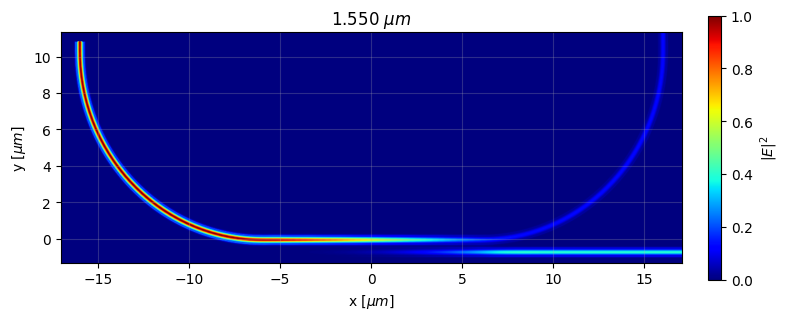

In [406]:
# Escala linear
fig1 = plt.figure(figsize=(8,8))
ax1 = fig1.add_subplot(111)
im1 = ax1.imshow(np.rot90(eField[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet')

colorbar = plt.colorbar(im1,fraction = 0.02, pad =0.04, label = r'$|E|^2$')

ax1.set_xlabel(r'x [$\mu m$]')
ax1.set_ylabel(r'y [$\mu m$]')
ax1.set_title(r'%4.3f $\mu m$' % (central_wavelength[indxLambda,0]/ um))
ax1.grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

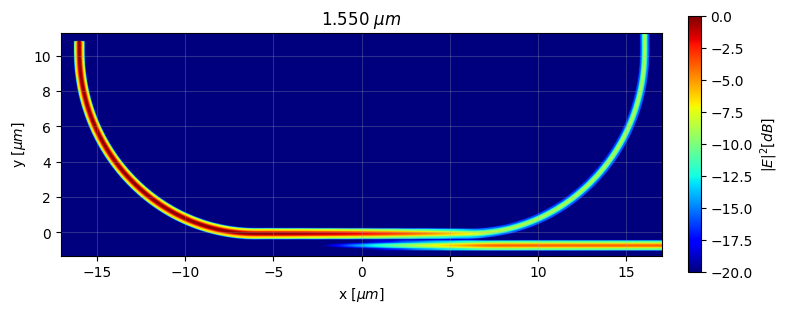

In [407]:
# Escala log

fig2 = plt.figure(figsize=(8,8))
ax2 = fig2.add_subplot(111)
im2 = ax2.imshow(10*np.log10(np.rot90(eField[:,:,indxLambda])), extent=[xmin, xmax, ymin, ymax], vmin = -20, vmax = 0, cmap = 'jet')

colorbar = plt.colorbar(im2,fraction = 0.02, pad =0.04, label = r'$|E|^2 [dB$]')

ax2.set_xlabel(r'x [$\mu m$]')
ax2.set_ylabel(r'y [$\mu m$]')
ax2.set_title(r'%4.3f $\mu m$' % (central_wavelength[indxLambda,0]/ um))
ax2.grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

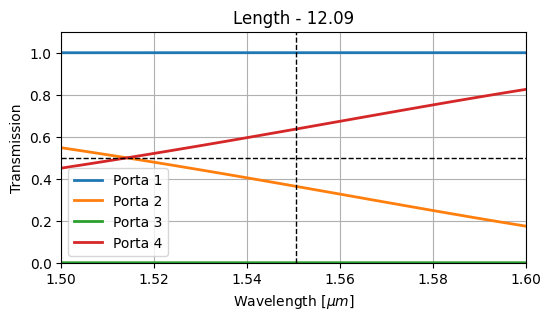

In [408]:
#Transmissão do dispositivo em cada porta
fig3 = plt.figure(figsize=(6,3))
for i in range(1,5,1):
    ports = fdtdApi.getresult('FDTD::ports::port_%d' %i, 'T')
    plt.plot(ports['lambda']/um, np.abs(ports['T']), label = 'Porta %d' %i, linewidth = 2)

plt.axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
plt.axhline(0.5, color = 'k', linestyle = '--', linewidth = 1)

plt.xlabel(r'Wavelength [$\mu m$]')
plt.ylabel(r'Transmission')
plt.xlim([start_wavelength/um, stop_wavelength/um])
plt.ylim([0,1.1])
plt.title(r'Length - %.2f' % (Lc/um))
plt.grid(True)
plt.legend(loc = 'best')
plt.show()

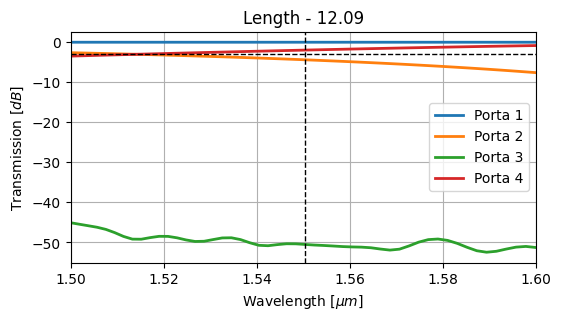

In [409]:
#Transmissão do dispositivo em cada porta em dB
fig4 = plt.figure(figsize=(6,3))
for i in range(1,5,1):
    ports_dB = fdtdApi.getresult('FDTD::ports::port_%d' %i, 'T')
    plt.plot(ports_dB['lambda']/um, 10*np.log10(np.abs(ports_dB['T'])), label = 'Porta %d' %i, linewidth = 2)

plt.axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
plt.axhline(-3, color = 'k', linestyle = '--', linewidth = 1)

plt.xlabel(r'Wavelength [$\mu m$]')
plt.ylabel(r'Transmission [$dB$]')
plt.xlim([start_wavelength/um, stop_wavelength/um])
#plt.ylim([0,1.1])
plt.title(r'Length - %.2f' % (Lc/um))
plt.grid(True)
plt.legend(loc = 'best')
plt.show()

## Otimização do dispositivo ##

In [410]:
from scipy.optimize import curve_fit

In [411]:
fdtdApi.switchtolayout()

Lc_start = 7.5*um
Lc_stop = 15*um
Lc_points = 14
Lc_array = np.linspace(Lc_start, Lc_stop, Lc_points)

In [412]:
ports = np.zeros([Lc_points,4, number_of_frequency_points])
fdtdApi.setnamed('movie', 'enabled', 0)
fdtdApi.setnamed('index', 'enabled', 0)
fdtdApi.setnamed('profile_xz', 'enabled', 0)

for i in range(0,len(Lc_array),1):
    Lc_wav = Lc_array[i]
    fdtdApi.switchtolayout()

    # Atualiza todos os objetos do guia

    fdtdApi.setnamed('core_1', 'x span', Lc_wav)
    fdtdApi.setnamed('90_bend_1', 'x', Lc_wav/2)
    fdtdApi.setnamed('90_bend_2', 'x', -Lc_wav/2)
    fdtdApi.setnamed('core_2', 'x span', Lc_wav + 2*rad)
    fdtdApi.setnamed('rect_1', 'x', -(rad + Lc_wav/2))
    fdtdApi.setnamed('rect_2', 'x', (rad + Lc_wav/2))
    fdtdApi.setnamed('rect_3', 'x', -(Lc_wav/2 + rad + 1*um))
    fdtdApi.setnamed('rect_4', 'x', Lc_wav/2 + rad + 1*um)

    fdtdApi.setnamed('FDTD', 'x span', Lc_wav + 2*rad + 2*um)
    fdtdApi.setnamed('profile_xy', 'x span', Lc_wav + 2*rad + 2*um)

    fdtdApi.setnamed('FDTD::ports::port_1', 'x', -(rad + Lc_wav/2))
    fdtdApi.setnamed('FDTD::ports::port_2', 'x', rad + Lc_wav/2)
    fdtdApi.setnamed('FDTD::ports::port_3', 'x', -(Lc_wav/2 + rad + 0.5*um))
    fdtdApi.setnamed('FDTD::ports::port_4', 'x', Lc_wav/2 + rad + 0.5*um)

    fdtdApi.run()
    for j in range(1,5,1):
        ports[i,j-1,:] = fdtdApi.getresult('FDTD::ports::port_%d' %j, 'T')['T']

wv1 = fdtdApi.getresult('FDTD::ports::port_1', 'T')['lambda']

fdtdApi.switchtolayout()
        

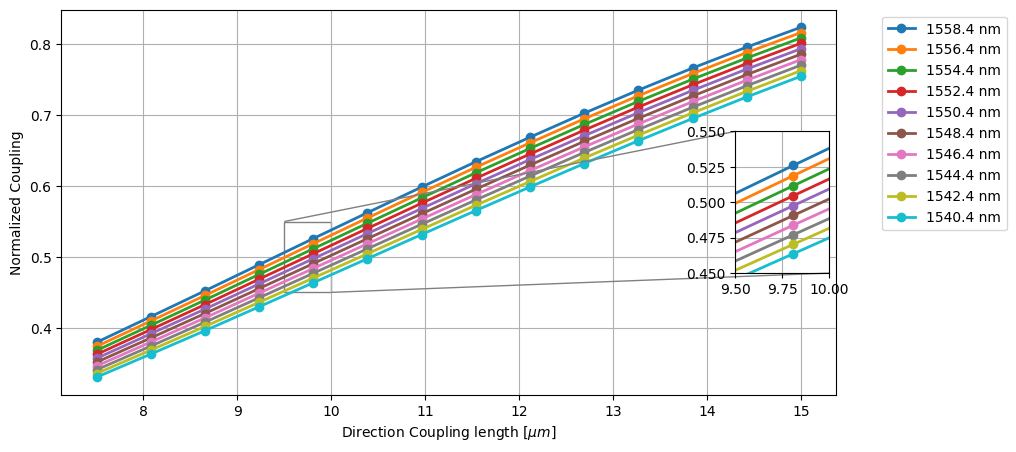

In [421]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(10,5))
for i in range(20,30,1):
    ax.plot(Lc_array/um, np.abs(ports[:,3,i]), 'o-', label = "%5.1f nm" %(wv1[i,0]/nm), linewidth = 2)

ax.set_xlabel(r'Direction Coupling length [$\mu m$]')
ax.set_ylabel('Normalized Coupling')
ax.legend(bbox_to_anchor=(1.05, 1), loc='best')
ax.grid(True)

axins = zoomed_inset_axes(ax, zoom = 2, loc = 'center right')
for i in range(20,30,1):
    axins.plot(Lc_array/um, np.abs(ports[:,3,i]), '-o', label = "%5.1f nm" %(wv1[i,0]/nm), linewidth = 2)

axins.set_xlim(9.5,10)
axins.set_ylim(0.45, 0.55)

axins.grid(True)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5", )
plt.draw()

plt.show()

In [414]:
# Tamanho optimizado para 50/50
Lc_ot = 9.8*um

fdtdApi.setnamed('movie', 'enabled', 1)
fdtdApi.setnamed('index', 'enabled', 1)
fdtdApi.setnamed('profile_xz', 'enabled', 1)
fdtdApi.setnamed('FDTD', 'mesh accuracy', 3)

fdtdApi.setnamed('core_1', 'x span', Lc_ot)
fdtdApi.setnamed('90_bend_1', 'x', Lc_ot/2)
fdtdApi.setnamed('90_bend_2', 'x', -Lc_ot/2)
fdtdApi.setnamed('core_2', 'x span', Lc_ot + 2*rad)
fdtdApi.setnamed('rect_1', 'x', -(rad + Lc_ot/2))
fdtdApi.setnamed('rect_2', 'x', (rad + Lc_ot/2))
fdtdApi.setnamed('rect_3', 'x', -(Lc_ot/2 + rad + 1*um))
fdtdApi.setnamed('rect_4', 'x', Lc_ot/2 + rad + 1*um)

fdtdApi.setnamed('FDTD', 'x span', Lc_ot + 2*rad + 2*um)
fdtdApi.setnamed('profile_xy', 'x span', Lc_ot + 2*rad + 2*um)

fdtdApi.setnamed('FDTD::ports::port_1', 'x', -(rad + Lc_ot/2))
fdtdApi.setnamed('FDTD::ports::port_2', 'x', rad + Lc_ot/2)
fdtdApi.setnamed('FDTD::ports::port_3', 'x', -(Lc_ot/2 + rad + 0.5*um))
fdtdApi.setnamed('FDTD::ports::port_4', 'x', Lc_ot/2 + rad + 0.5*um)

In [415]:
fdtdApi.run()

In [416]:
# importa o campo elétrico - abs**2
eField = np.abs(np.squeeze(fdtdApi.getelectric('profile_xy')))**2

x_efield = fdtdApi.getdata('profile_xy', 'x')
y_efield = fdtdApi.getdata('profile_xy', 'y')
central_wavelength = nu2lambda(fdtdApi.getdata('profile_xy', 'f'))
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

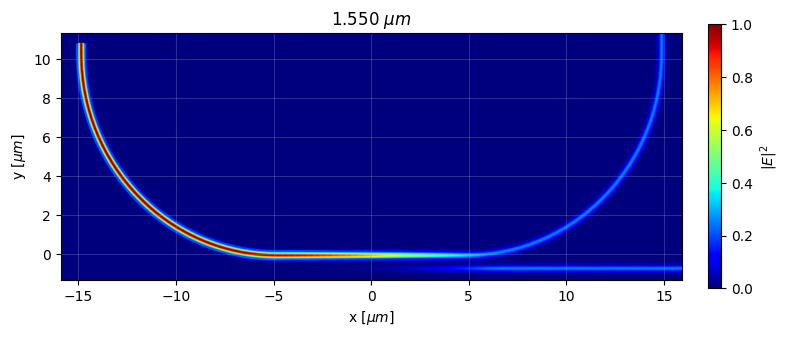

In [ ]:
# Escala linear
fig5 = plt.figure(figsize=(8,8))
ax3 = fig5.add_subplot(111)
im3 = ax3.imshow(np.rot90(eField[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet')

colorbar = plt.colorbar(im3,fraction = 0.02, pad =0.04, label = r'$|E|^2$')

ax3.set_xlabel(r'x [$\mu m$]')
ax3.set_ylabel(r'y [$\mu m$]')
ax3.set_title(r'%4.3f $\mu m$' % (central_wavelength[indxLambda,0]/ um))
ax3.grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

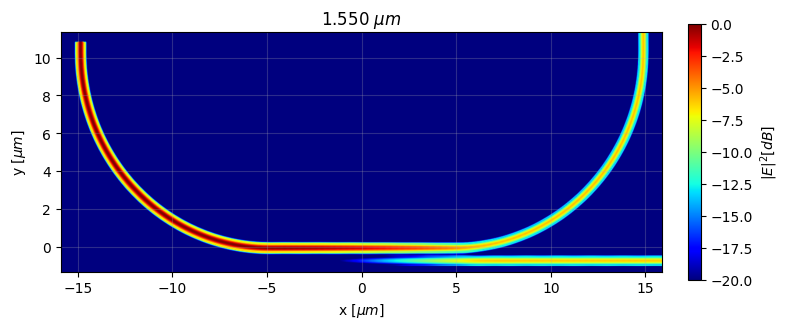

In [ ]:
# Escala log

fig6 = plt.figure(figsize=(8,8))
ax4 = fig6.add_subplot(111)
im4 = ax4.imshow(10*np.log10(np.rot90(eField[:,:,indxLambda])), extent=[xmin, xmax, ymin, ymax], vmin = -20, vmax = 0, cmap = 'jet')

colorbar = plt.colorbar(im4,fraction = 0.02, pad =0.04, label = r'$|E|^2 [dB$]')

ax4.set_xlabel(r'x [$\mu m$]')
ax4.set_ylabel(r'y [$\mu m$]')
ax4.set_title(r'%4.3f $\mu m$' % (central_wavelength[indxLambda,0]/ um))
ax4.grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

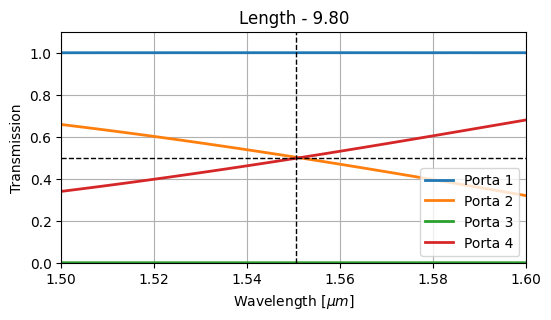

In [ ]:
#Transmissão do dispositivo em cada porta
fig7 = plt.figure(figsize=(6,3))
for i in range(1,5,1):
    ports_ot = fdtdApi.getresult('FDTD::ports::port_%d' %i, 'T')
    plt.plot(ports_ot['lambda']/um, np.abs(ports_ot['T']), label = 'Porta %d' %i, linewidth = 2)

plt.axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
plt.axhline(0.5, color = 'k', linestyle = '--', linewidth = 1)

plt.xlabel(r'Wavelength [$\mu m$]')
plt.ylabel(r'Transmission')
plt.xlim([start_wavelength/um, stop_wavelength/um])
plt.ylim([0,1.1])
plt.title(r'Length - %.2f' % (Lc_ot/um))
plt.grid(True)
plt.legend(loc = 'lower right')
plt.show()

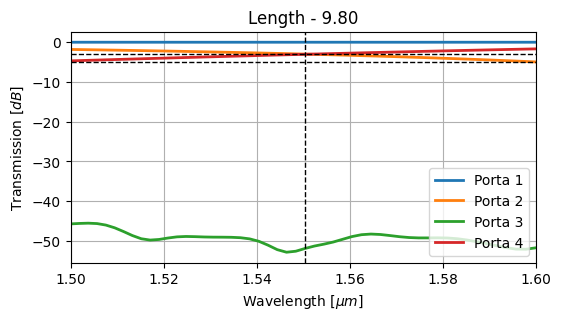

In [ ]:
#Transmissão do dispositivo em cada porta em dB
fig8 = plt.figure(figsize=(6,3))
for i in range(1,5,1):
    ports_ot_dB = fdtdApi.getresult('FDTD::ports::port_%d' %i, 'T')
    plt.plot(ports_ot_dB['lambda']/um, 10*np.log10(np.abs(ports_ot_dB['T'])), label = 'Porta %d' %i, linewidth = 2)

plt.axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
plt.axhline(-3, color = 'k', linestyle = '--', linewidth = 1)
plt.axhline(-5, color = 'k', linestyle = '--', linewidth = 1)

plt.xlabel(r'Wavelength [$\mu m$]')
plt.ylabel(r'Transmission [$dB$]')
plt.xlim([start_wavelength/um, stop_wavelength/um])
#plt.ylim([0,1.1])
plt.title(r'Length - %.2f' % (Lc_ot/um))
plt.grid(True)
plt.legend(loc = 'lower right')
plt.show()

## Simulação - Modo TM ##

In [446]:
fdtdApi.switchtolayout()

z_min_bc = 'Anti-Symmetric'

for i in range(1,5,1):
    fdtdApi.setnamed('FDTD::ports::port_%d' %i, 'mode selection', 'fundamental TM mode')

fdtdApi.setnamed('FDTD', 'z min bc', z_min_bc)

In [447]:
fdtdApi.save('Directional_coupler_FDTD')
fdtdApi.run()

In [ ]:
# importa o campo elétrico - abs**2
eField = np.abs(np.squeeze(fdtdApi.getelectric('profile_xy')))**2

x_efield = fdtdApi.getdata('profile_xy', 'x')
y_efield = fdtdApi.getdata('profile_xy', 'y')
central_wavelength = nu2lambda(fdtdApi.getdata('profile_xy', 'f'))
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

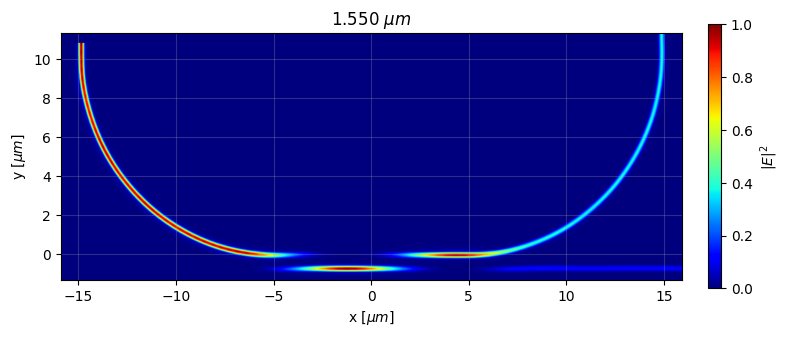

In [464]:
# Escala linear
eField_normalized = eField[:,:,indxLambda]/np.max(eField[:,:,indxLambda])

fig9 = plt.figure(figsize=(8,8))
ax5 = fig9.add_subplot(111)
im5 = ax5.imshow(np.rot90(eField_normalized), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet')

colorbar = plt.colorbar(im5,fraction = 0.02, pad =0.04, label = r'$|E|^2$')

ax5.set_xlabel(r'x [$\mu m$]')
ax5.set_ylabel(r'y [$\mu m$]')
ax5.set_title(r'%4.3f $\mu m$' % (central_wavelength[indxLambda,0]/ um))
ax5.grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

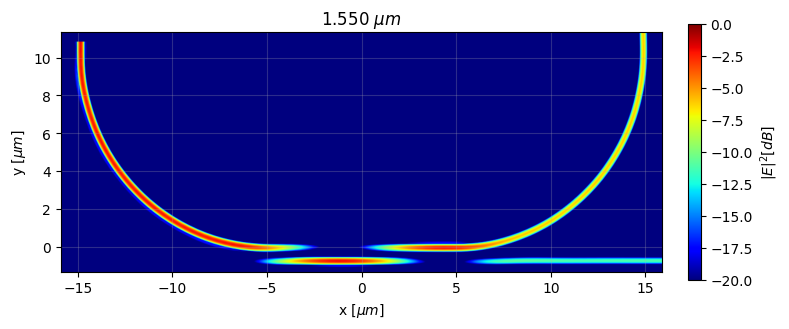

In [ ]:
# Escala log

fig10 = plt.figure(figsize=(8,8))
ax6 = fig10.add_subplot(111)
im6 = ax6.imshow(10*np.log10(np.rot90(eField_normalized)), extent=[xmin, xmax, ymin, ymax], vmin = -20, vmax = 0, cmap = 'jet')

colorbar = plt.colorbar(im6,fraction = 0.02, pad =0.04, label = r'$|E|^2 [dB$]')

ax6.set_xlabel(r'x [$\mu m$]')
ax6.set_ylabel(r'y [$\mu m$]')
ax6.set_title(r'%4.3f $\mu m$' % (central_wavelength[indxLambda,0]/ um))
ax6.grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

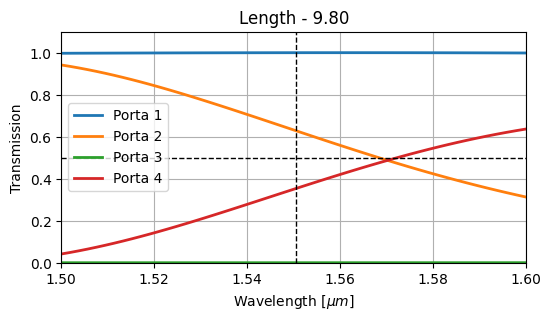

In [451]:
#Transmissão do dispositivo em cada porta
fig10 = plt.figure(figsize=(6,3))
for i in range(1,5,1):
    ports_TM = fdtdApi.getresult('FDTD::ports::port_%d' %i, 'T')
    plt.plot(ports_TM['lambda']/um, np.abs(ports_TM['T']), label = 'Porta %d' %i, linewidth = 2)

plt.axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
plt.axhline(0.5, color = 'k', linestyle = '--', linewidth = 1)

plt.xlabel(r'Wavelength [$\mu m$]')
plt.ylabel(r'Transmission')
plt.xlim([start_wavelength/um, stop_wavelength/um])
plt.ylim([0,1.1])
plt.title(r'Length - %.2f' % (Lc_ot/um))
plt.grid(True)
plt.legend(loc = 'best')
plt.show()

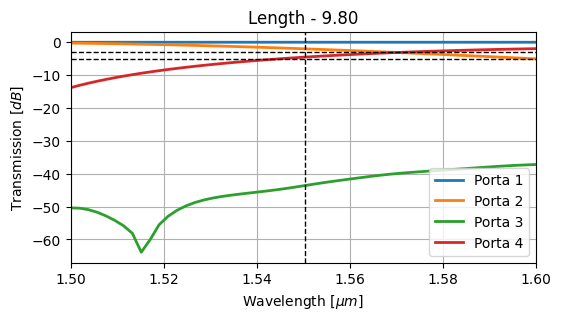

In [452]:
#Transmissão do dispositivo em cada porta em dB
fig11 = plt.figure(figsize=(6,3))
for i in range(1,5,1):
    ports_TM_dB = fdtdApi.getresult('FDTD::ports::port_%d' %i, 'T')
    plt.plot(ports_TM_dB['lambda']/um, 10*np.log10(np.abs(ports_TM_dB['T'])), label = 'Porta %d' %i, linewidth = 2)

plt.axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
plt.axhline(-3, color = 'k', linestyle = '--', linewidth = 1)
plt.axhline(-5, color = 'k', linestyle = '--', linewidth = 1)

plt.xlabel(r'Wavelength [$\mu m$]')
plt.ylabel(r'Transmission [$dB$]')
plt.xlim([start_wavelength/um, stop_wavelength/um])
#plt.ylim([0,1.1])
plt.title(r'Length - %.2f' % (Lc_ot/um))
plt.grid(True)
plt.legend(loc = 'lower right')
plt.show()